## 1) Imports & Global Configuration

This section initializes required libraries, suppresses warnings for cleaner outputs,

and establishes global seeds to guarantee absolute reproducibility across all environments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import optuna

# Global Random Seed for reproducibility
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)


## 2) Custom Transformers

Custom Scikit-Learn compatible transformers for feature selection and dimensionality reduction.

These maintain DataFrame structures for sequential processing in pipelines.

In [2]:
class DuplicateFeatureFilter(BaseEstimator, TransformerMixin):
    """Removes duplicate features (identical columns)."""

    def fit(
        self, X: pd.DataFrame | np.ndarray, y: pd.Series | None = None
    ) -> "DuplicateFeatureFilter":
        X = pd.DataFrame(X)
        self.columns_ = X.columns

        # Transpose trick to detect duplicate columns
        self.keep_cols_ = X.T.drop_duplicates().T.columns

        return self

    def transform(self, X: pd.DataFrame | np.ndarray) -> pd.DataFrame:
        X = pd.DataFrame(X, columns=self.columns_)
        return X[self.keep_cols_]


In [3]:
class VarianceFilter(BaseEstimator, TransformerMixin):
    """Removes features with variance below a certain threshold while returning a DataFrame."""

    def __init__(self, threshold: float = 0.01):
        self.threshold = threshold

    def fit(
        self, X: pd.DataFrame | np.ndarray, y: pd.Series | None = None
    ) -> "VarianceFilter":
        X = pd.DataFrame(X)
        self.columns_ = X.columns

        self.selector_ = VarianceThreshold(self.threshold)
        self.selector_.fit(X)

        # Retain columns that passed the variance threshold
        self.keep_cols_ = X.columns[self.selector_.get_support()]
        return self

    def transform(self, X: pd.DataFrame | np.ndarray) -> pd.DataFrame:
        X = pd.DataFrame(X, columns=self.columns_)
        return X[self.keep_cols_]


In [4]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Removes highly correlated features to reduce multicollinearity."""

    def __init__(self, threshold: float = 0.95):
        self.threshold = threshold

    def fit(self, X: pd.DataFrame | np.ndarray, y: pd.Series) -> "CorrelationFilter":
        X = pd.DataFrame(X)
        self.columns_ = X.columns

        y = pd.Series(y)

        corr_matrix = X.corr().abs()
        feature_corr = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # correlation of features with target
        mi_scores = mutual_info_classif(X, y)
        target_corr = pd.Series(mi_scores, index=X.columns)

        to_drop: set[str] = set()

        for feature_1 in feature_corr.columns:
            for feature_2 in feature_corr.index:
                if feature_corr.loc[feature_2, feature_1] > self.threshold:

                    # compare both features vs target
                    if target_corr[feature_1] < target_corr[feature_2]:
                        to_drop.add(feature_1)
                    else:
                        to_drop.add(feature_2)

        self.keep_cols_ = [c for c in X.columns if c not in to_drop]
        return self

    def transform(self, X: pd.DataFrame | np.ndarray) -> pd.DataFrame:
        X = pd.DataFrame(X, columns=self.columns_)
        return X[self.keep_cols_]

# # Random remove one of the two features that are highly correlated
# class CorrelationFilter(BaseEstimator, TransformerMixin):
#     """Removes highly correlated features to reduce multicollinearity."""
#     def __init__(self, threshold=0.95):
#         self.threshold = threshold

#     def fit(self, X, y=None):
#         X = pd.DataFrame(X)
#         self.columns_ = X.columns  

#         # Compute absolute correlation matrix
#         corr = X.corr().abs()

#         # Extract the upper triangle of the correlation matrix to avoid redundant checks
#         upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

#         # Identify columns to drop based on the threshold
#         self.to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
#         self.keep_cols_ = [col for col in X.columns if col not in self.to_drop_]

#         return self

#     def transform(self, X):
#         X = pd.DataFrame(X, columns=self.columns_)  
#         return X[self.keep_cols_]   

In [5]:
class GroupwisePCA(BaseEstimator, TransformerMixin):
    """Applies PCA separately to distinct logical groups of features (e.g., time vs. frequency domains)."""

    def __init__(
        self,
        freq_var: float = 0.90,
        time_var: float = 0.95,
        random_state: int = RANDOM_SEED,
    ):
        self.freq_var = freq_var
        self.time_var = time_var
        self.random_state = random_state

    def fit(
        self, X: pd.DataFrame | np.ndarray, y: pd.Series | None = None
    ) -> "GroupwisePCA":
        X = pd.DataFrame(X)
        self.columns_ = X.columns
        self.groupwise_report_: list[dict] = []

        # Extract base group names from columns (assuming format 'group-metric(...)')
        group_map = (
            X.columns.to_series()
            .groupby(X.columns.map(lambda c: c.split("-")[0].split("(")[0]))
            .apply(list)
        )

        self.group_models_: list[dict] = []

        for group_name, cols in group_map.items():
            Xg = X[cols]

            # Features must be scaled before applying PCA
            scaler = StandardScaler()
            Xg_scaled = scaler.fit_transform(Xg)

            # Apply different variance retention thresholds based on domain (frequency vs time)
            if group_name.startswith("f"):
                var = self.freq_var
            else:
                var = self.time_var

            pca = PCA(n_components=var, random_state=self.random_state)
            pca.fit(Xg_scaled)

            # Log dimensionality reduction statistics for analytical reporting
            self.groupwise_report_.append(
                {
                    "group": group_name,
                    "n_features_before": Xg.shape[1],
                    "n_features_after": pca.n_components_,
                    "explained_variance": float(pca.explained_variance_ratio_.sum()),
                }
            )

            self.group_models_.append({"cols": cols, "scaler": scaler, "pca": pca})

        return self

    def transform(self, X: pd.DataFrame | np.ndarray) -> np.ndarray:
        X = pd.DataFrame(X, columns=self.columns_)

        parts: list[np.ndarray] = []
        # Transform each group independently and concatenate the principal components
        for item in self.group_models_:
            Xg = X[item["cols"]]
            Xg_scaled = item["scaler"].transform(Xg)
            Xg_pca = item["pca"].transform(Xg_scaled)
            parts.append(Xg_pca)

        return np.hstack(parts)

    def get_groupwise_report_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.groupwise_report_)


In [6]:
def build_model(params: dict) -> Pipeline:
    """Constructs the complete Scikit-Learn Pipeline using the provided hyperparameters."""
    prep = Pipeline(
        [
            ("dup", DuplicateFeatureFilter()),
            ("var", VarianceFilter(params["var_th"])),
            ("corr", CorrelationFilter(params["corr_th"])),
            ("group_pca", GroupwisePCA(params["group_pca"], params["group_pca"])),
            ("final_pca", PCA(params["final_pca"], random_state=RANDOM_SEED)),
        ]
    )

    model = Pipeline(
        [
            ("prep", prep),
            (
                "svm",
                SVC(
                    C=params["C"],
                    kernel=params["kernel"],
                    gamma=params["gamma"],
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    return model


## 3) Data Loading & Exploratory Data Analysis (EDA)

Ingest the dataset, separate features from the target variable, and perform baseline visualizations.

In [7]:
train_df = pd.read_csv("data/train.csv")

X_train = train_df.drop(columns=["Activity", "subject"])
y_train = train_df["Activity"]

print("=== Dataset Info ===")
print(f"Train Data Shape: {X_train.shape}")
print(f"Target Classes: {sorted(y_train.unique())}")

feature_groups = pd.Series(
    [c.split("-")[0].split("(")[0] for c in X_train.columns]
).value_counts()
print("\n=== Feature Groups Size ===")
print(f"{feature_groups.shape[0]} groups with {feature_groups.sum()} total features")
print("\n=== Feature Groups Distribution ===")
print(feature_groups)


=== Dataset Info ===
Train Data Shape: (7352, 561)
Target Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']

=== Feature Groups Size ===
18 groups with 561 total features

=== Feature Groups Distribution ===
fBodyAcc                79
fBodyAccJerk            79
fBodyGyro               79
tBodyAcc                40
tGravityAcc             40
tBodyAccJerk            40
tBodyGyro               40
tBodyGyroJerk           40
tBodyAccMag             13
tGravityAccMag          13
tBodyAccJerkMag         13
tBodyGyroMag            13
tBodyGyroJerkMag        13
fBodyAccMag             13
fBodyBodyAccJerkMag     13
fBodyBodyGyroMag        13
fBodyBodyGyroJerkMag    13
angle                    7
Name: count, dtype: int64


In [8]:
# ── 4.1 Missing values ──────────────────────────────────────────────────────
print("=== Missing Values ===")
print(f"Train: {train_df.isnull().sum().sum()}")
# No missing values — nothing to impute.


=== Missing Values ===
Train: 0


In [9]:
# ── 4.2 Duplicate rows ──────────────────────────────────────────────────────
print(f"Duplicate rows in train : {train_df.duplicated().sum()}")
# No duplicates found — no records dropped.


Duplicate rows in train : 0


In [10]:
# ── 4.4 Near-zero variance features ─────────────────────────────────────────
var_series = X_train.var()
nzv_features = var_series[var_series < 0.01].index.tolist()
print(f"Near-zero variance features removed: {len(nzv_features)}")


Near-zero variance features removed: 37


In [11]:
# ── 4.5 Duplicate feature columns ───────────────────────────────────────────
before = train_df.shape[1]
duplicates = train_df.T.duplicated().sum()
print(f"Duplicate columns : {duplicates}")


Duplicate columns : 21


/tmp/ipykernel_26894/1865235982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


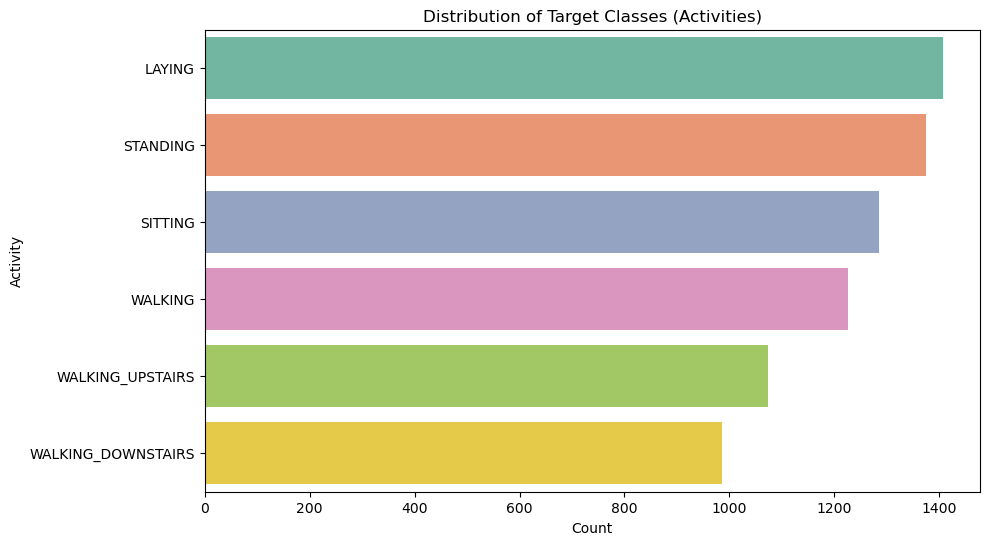

In [12]:
# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(
    y="Activity",
    data=train_df,
    order=train_df["Activity"].value_counts().index,
    palette="Set2",
)
plt.title("Distribution of Target Classes (Activities)")
plt.xlabel("Count")
plt.ylabel("Activity")
plt.show()


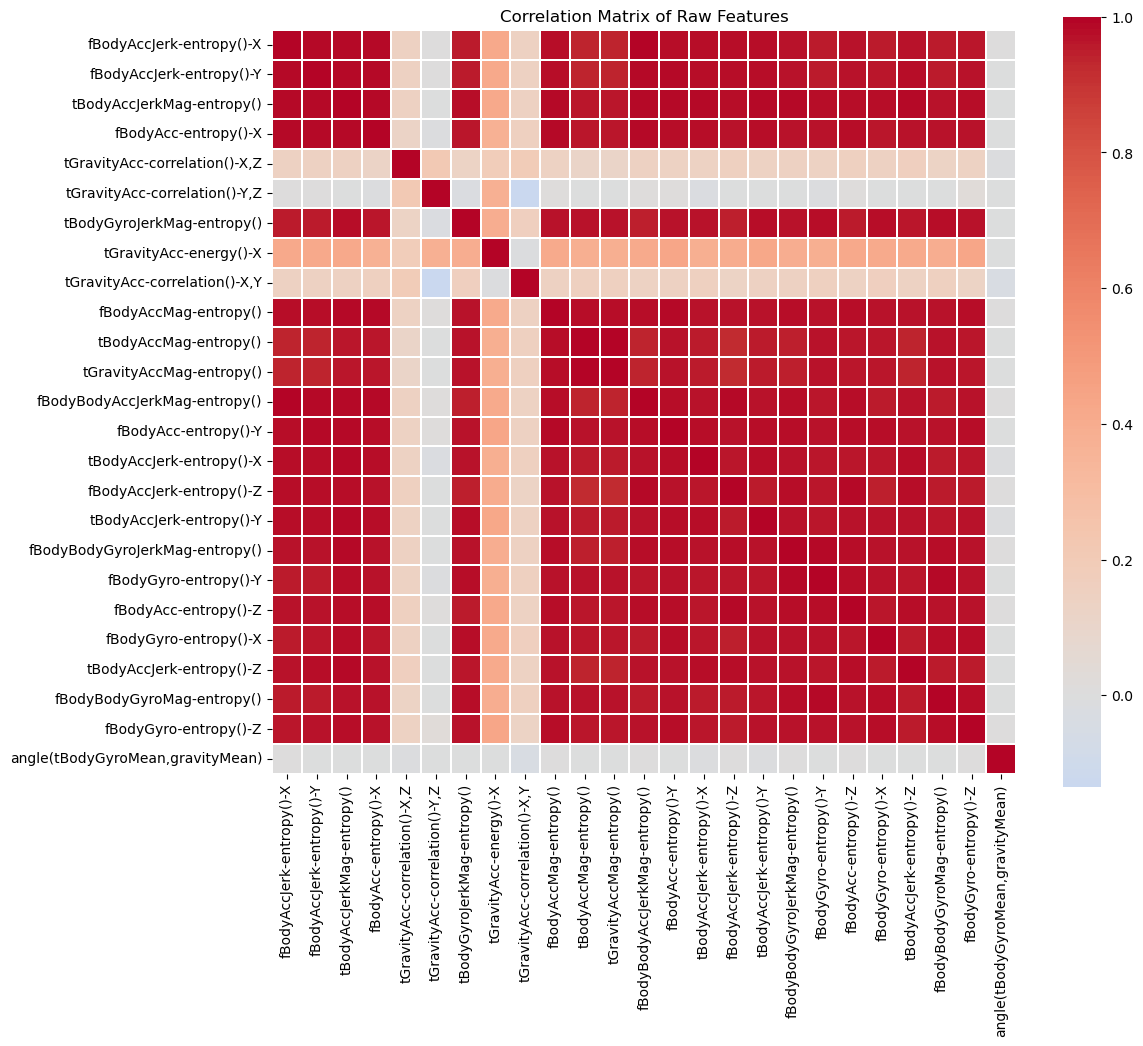

In [13]:
# Plot Feature Correlation Matrix
top20 = X_train.var().nlargest(25).index.tolist()
corr = X_train[top20].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(data=corr, cmap="coolwarm", center=0, square=True, linewidths=0.01)
plt.title("Correlation Matrix of Raw Features")
plt.show()


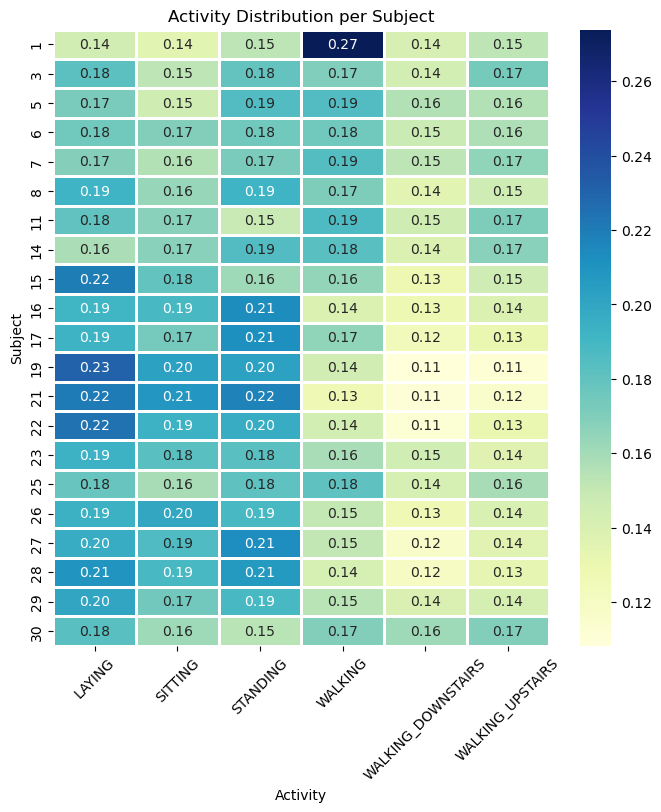

In [14]:
subj_act = train_df.groupby(["subject", "Activity"]).size().unstack(fill_value=0)
subj_act_dist = subj_act.div(subj_act.sum(axis=1), axis=0)

plt.figure(figsize=(8, 8))
sns.heatmap(subj_act_dist, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=1)

plt.title("Activity Distribution per Subject")
plt.xlabel("Activity")
plt.ylabel("Subject")
plt.xticks(rotation=45)
plt.show()


## 4) Hyperparameter Tuning & Cross-Validation

Optimize the pipeline hyperparameters using Optuna with a Stratified K-Fold approach.

In [15]:
# 4.1 Evaluate Baseline Model
svm_pipeline = build_model(
    {
        "var_th": 0.01,
        "corr_th": 0.95,
        "group_pca": 0.90,
        "final_pca": 0.98,
        "C": 1.0,
        "kernel": "rbf",
        "gamma": "scale",
    }
)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

baseline_cv_scores = cross_val_score(
    svm_pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
)

print("\n=== Baseline SVM Performance ===")
print(f"Baseline CV accuracy (mean): {float(baseline_cv_scores.mean()):.4f}")



=== Baseline SVM Performance ===
Baseline CV accuracy (mean): 0.9622


In [16]:
# 4.2 Optuna Optimization
SEARCH_SPACE = {
    "var_th": (0.0, 0.02),
    "corr_th": (0.90, 0.97),
    "group_pca": (0.90, 0.99),
    "final_pca": (0.95, 0.99),
    "C": (0.1, 100),
    "kernel": ["rbf", "linear", "poly"],
    "gamma": ["scale", 0.1, 0.01, 0.001],
}


def objective(trial) -> float:
    params: dict = {
        "var_th": trial.suggest_float("var_th", *SEARCH_SPACE["var_th"]),
        "corr_th": trial.suggest_float("corr_th", *SEARCH_SPACE["corr_th"]),
        "group_pca": trial.suggest_float("group_pca", *SEARCH_SPACE["group_pca"]),
        "final_pca": trial.suggest_float("final_pca", *SEARCH_SPACE["final_pca"]),
        "C": trial.suggest_float("C", *SEARCH_SPACE["C"], log=True),
        "kernel": trial.suggest_categorical("kernel", SEARCH_SPACE["kernel"]),
        "gamma": trial.suggest_categorical("gamma", SEARCH_SPACE["gamma"]),
    }

    model = build_model(params)

    score: float = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
    ).mean()

    return score


# Ensure Optuna sampler is seeded for full reproducibility
optuna.logging.set_verbosity(optuna.logging.INFO)
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=2)

best_params: dict = study.best_params
best_score: float = study.best_value

print("\n=== Optimization Results ===")
print(f"Best Optuna Objective Score: {best_score:.4f}")
print(f"Best Discovered Parameters: {best_params}")


[I 2026-05-03 14:54:31,242] A new study created in memory with name: no-name-a6ad419a-63ae-4829-8a96-f13055ae7c9b
[I 2026-05-03 14:55:07,928] Trial 0 finished with value: 0.27067480439748315 and parameters: {'var_th': 0.00749080237694725, 'corr_th': 0.9665500014486941, 'group_pca': 0.9658794547630265, 'final_pca': 0.9739463393678814, 'C': 0.2938027938703535, 'kernel': 'poly', 'gamma': 0.001}. Best is trial 0 with value: 0.27067480439748315.
[I 2026-05-03 14:55:29,881] Trial 1 finished with value: 0.96218675148558 and parameters: {'var_th': 0.016648852816008437, 'corr_th': 0.9148637377474793, 'group_pca': 0.9163642470486391, 'final_pca': 0.9573361803941374, 'C': 0.8179499475211672, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.96218675148558.



=== Optimization Results ===
Best Optuna Objective Score: 0.9622
Best Discovered Parameters: {'var_th': 0.016648852816008437, 'corr_th': 0.9148637377474793, 'group_pca': 0.9163642470486391, 'final_pca': 0.9573361803941374, 'C': 0.8179499475211672, 'kernel': 'rbf', 'gamma': 'scale'}


## 5) Final Pipeline Training & Validation

Train the model with the optimal parameters on the full training set, compute validation metrics,

and track dimensionality reduction layers.


=== Dimensionality Reduction Layers (Train) ===
Original features             : 561
After duplicate filter          : 540
After low variance filter     : 470
After high correlation filter : 185
After group-wise PCA          : 127
After final PCA               : 86

=== Groupwise PCA Report ===
                   group  n_features_before  n_features_after  \
0                  angle                  4                 4   
1               fBodyAcc                 16                11   
2           fBodyAccJerk                 18                12   
3            fBodyAccMag                  4                 4   
4    fBodyBodyAccJerkMag                  4                 4   
5   fBodyBodyGyroJerkMag                  4                 4   
6       fBodyBodyGyroMag                  4                 4   
7              fBodyGyro                 16                12   
8               tBodyAcc                 17                 9   
9           tBodyAccJerk                 20           

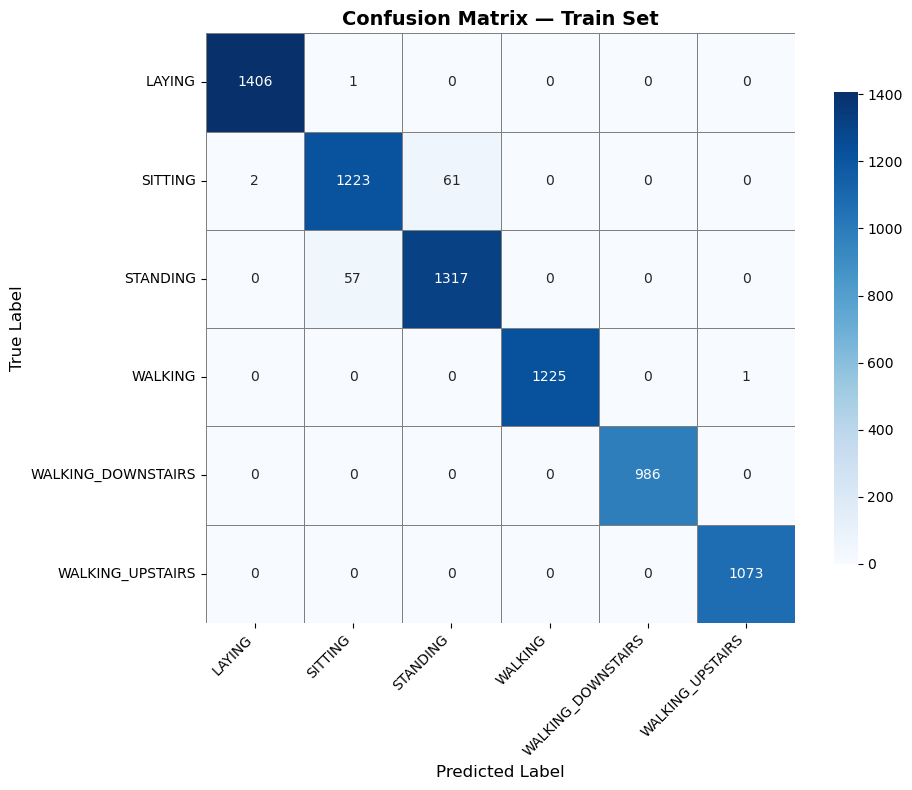

In [17]:
best_model = build_model(best_params)

best_cv_scores_train = cross_val_score(
    best_model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
)
best_model.fit(X_train, y_train)

mean_cv_train = np.mean(best_cv_scores_train)
std_cv_train = np.std(best_cv_scores_train)
y_pred_train = best_model.predict(X_train)

# Analyze feature counts through the pipeline steps
prep = best_model.named_steps["prep"]
X_tmp = X_train.copy()

X_tmp = prep.named_steps["dup"].transform(X_tmp)
after_dup = X_tmp.shape[1]

X_tmp = prep.named_steps["var"].transform(X_tmp)
after_var = X_tmp.shape[1]

X_tmp = prep.named_steps["corr"].transform(X_tmp)
after_corr = X_tmp.shape[1]

X_tmp = prep.named_steps["group_pca"].transform(X_tmp)
after_group = X_tmp.shape[1]

X_tmp = prep.named_steps["final_pca"].transform(X_tmp)
after_final = X_tmp.shape[1]

print("\n=== Dimensionality Reduction Layers (Train) ===")
print(f"Original features             : {X_train.shape[1]}")
print(f"After duplicate filter          : {after_dup}")
print(f"After low variance filter     : {after_var}")
print(f"After high correlation filter : {after_corr}")
print(f"After group-wise PCA          : {after_group}")
print(f"After final PCA               : {after_final}")

# Groupwise PCA statistics
group_report = prep.named_steps["group_pca"].get_groupwise_report_df()
print("\n=== Groupwise PCA Report ===")
print(group_report)

print(f"\n=== Cross-Validation Performance (Train Set) ===")
print(f"Mean CV accuracy: {mean_cv_train:.4f}")
print(f"Standard deviation: {std_cv_train:.4f}")
print(f"Accuracy: mean ± std = {mean_cv_train:.4f} ± {std_cv_train:.4f}")

print("\n=== Classification Report (Train Set) ===\n")
print(classification_report(y_train, y_pred_train))

# Visualize confusion matrix (Train)
cm_train = confusion_matrix(y_train, y_pred_train, labels=best_model.classes_)
cm_train_df = pd.DataFrame(
    cm_train, index=best_model.classes_, columns=best_model.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_train_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Confusion Matrix — Train Set", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 6) Final Test Evaluation

Evaluate the finalized model against the unseen test dataset.


=== Tuned SVM (Test Evaluation) ===
Final Best CV accuracy (Train): 0.9622
Final Test accuracy  : 0.9284

=== Classification Report (Test Set) ===

                    precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       537
           SITTING       0.89      0.89      0.89       491
          STANDING       0.91      0.94      0.92       532
           WALKING       0.93      0.98      0.95       496
WALKING_DOWNSTAIRS       0.93      0.91      0.92       420
  WALKING_UPSTAIRS       0.93      0.89      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



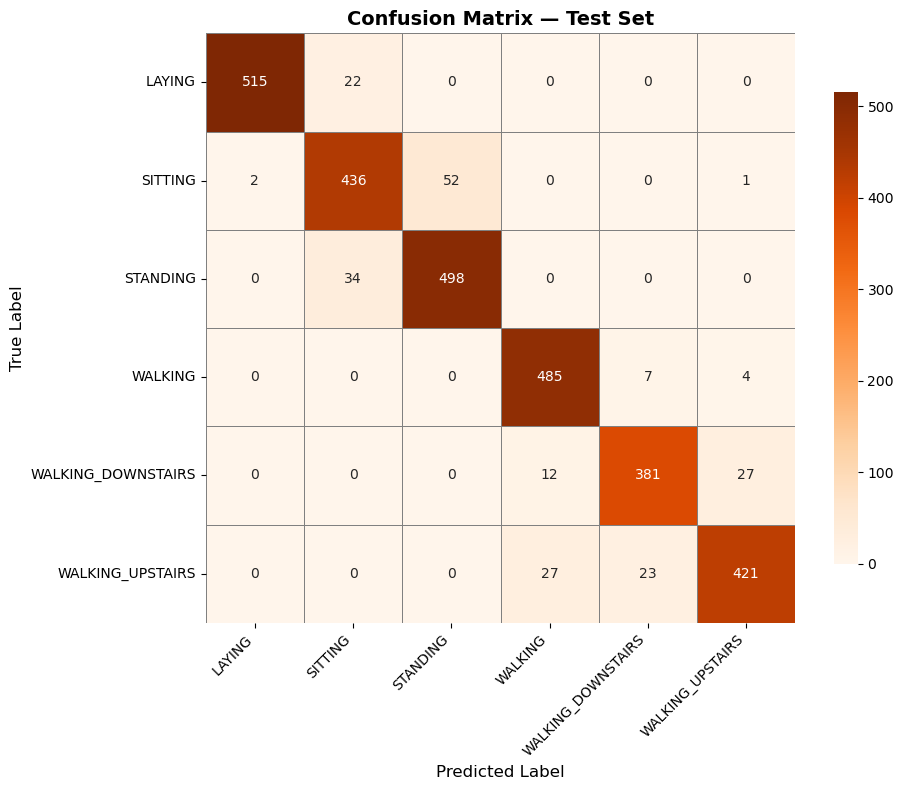

In [18]:
test_df = pd.read_csv("data/test.csv").drop(columns=["subject"])

X_test = test_df.drop(columns=["Activity"])
y_test = test_df["Activity"]

y_pred_test = best_model.predict(X_test)
test_score = accuracy_score(y_test, y_pred_test)

print("\n=== Tuned SVM (Test Evaluation) ===")
print(f"Final Best CV accuracy (Train): {best_score:.4f}")
print(f"Final Test accuracy  : {test_score:.4f}")

print("\n=== Classification Report (Test Set) ===\n")
print(classification_report(y_test, y_pred_test))

# Visualize confusion matrix (Test)
cm_test = confusion_matrix(y_test, y_pred_test, labels=best_model.classes_)
cm_test_df = pd.DataFrame(
    cm_test, index=best_model.classes_, columns=best_model.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test_df,
    annot=True,
    fmt="d",
    cmap="Oranges",
    linewidths=0.5,
    linecolor="gray",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:
print("\n" + "=" * 40)
print(" FINAL CONCLUSION ")
print("=" * 40)
print(
    f"Cross-validation Accuracy (Train Set) : {mean_cv_train:.4f} ± {std_cv_train:.4f}"
)
print(f"Hold-out Accuracy (Test Set)          : {test_score:.4f}")
print("=" * 40)



 FINAL CONCLUSION 
Cross-validation Accuracy (Train Set) : 0.9627 ± 0.0025
Hold-out Accuracy (Test Set)          : 0.9284


In [20]:
# Save the best model for future use 
import joblib
joblib.dump(best_model, "best_svm_pipeline.pkl")

['best_svm_pipeline.pkl']